In [2]:
# ドライブのマウント
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# カレントディレクトリの移動・確認
%cd drive/MyDrive/cnn_visualization_workspace
!pwd

/content/drive/MyDrive/cnn_visualization_workspace
/content/drive/MyDrive/cnn_visualization_workspace


In [4]:
# ライブラリのインポート
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.models import Model

In [5]:
# 学習用データセットフォルダ
dataset_dir = '/content/drive/MyDrive/cnn_visualization_workspace/data/collection/Bing/resize'

# 訓練・検証用に分割（8:2）
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(256, 256),
    batch_size=32,
    label_mode='int'  # クラスは整数（0 or 1）
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(256, 256),
    batch_size=32,
    label_mode='int'
)

Found 404 files belonging to 2 classes.
Using 324 files for training.
Found 404 files belonging to 2 classes.
Using 80 files for validation.


In [6]:
print(train_ds.class_names)

['Dachshund', 'French_Bulldog']


In [21]:
# ベースCNNモデル（Functional API）
def build_functional_simple_cnn(input_shape=(256, 256, 3), num_classes=2):
    inputs = Input(shape=input_shape)

    # 特徴抽出部（Conv層）
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='conv1')(inputs)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)

    # 分類部
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="SimpleCNN")
    return model

# モデルを作成
model = build_functional_simple_cnn()
model.summary()

# 特徴マップの可視化
def visualize_feature_maps(feature_map, layer_name, num_display=8):
    num_filters = feature_map.shape[-1]
    plt.figure(figsize=(24, 24))
    for i in range(min(num_display, num_filters)):
        plt.subplot(8, 8, i + 1)
        plt.imshow(feature_map[0, :, :, i], cmap='viridis')
        plt.axis('off')
        plt.title(f'{layer_name} - Filter {i}')
    plt.suptitle(f"{layer_name} Feature Maps")
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()

# 特徴マップの差分をから変化をヒートマップ化
def visualize_diff_heat_maps(before_feature_map, after_feature_maps,layer_name, num_display=8):
    num_filters = before_feature_map.shape[-1]
    plt.figure(figsize=(24, 24))
    for i in range(min(num_display, num_filters)):
        diff_map = after_feature_maps[0, :, :, i] - before_feature_map[0, :, :, i]
        plt.subplot(8, 8, i + 1)
        # 青＝弱くなった, 赤＝強くなった
        plt.imshow(diff_map, cmap='seismic')
        plt.axis('off')
        plt.title(f'{layer_name} - Filter {i}')
    plt.suptitle(f"{layer_name} Difference Map Blue=weak, Red=strong")
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()

Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     8,388,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,393,890 (32.02 MB)

 Trainable params: 8,393,890 (32.02 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# conv1, pool1, conv2 の出力を定義
activation_model = Model(
    inputs=model.input,
    outputs=[
        model.get_layer('conv1').output,
        model.get_layer('pool1').output,
        model.get_layer('conv2').output
    ]
)

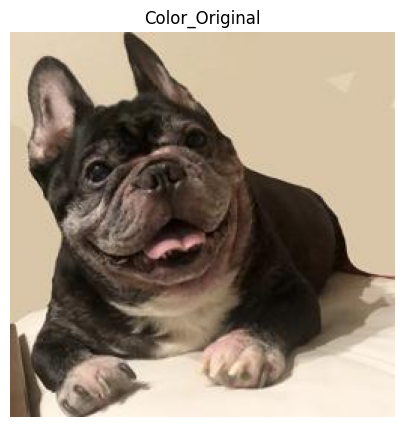

In [22]:
# 画像読み込み（カラー）
img_color = cv2.imread("data/input/bubu_256_1.jpg", cv2.IMREAD_COLOR)
# BGR → RGB に変換（matplotlib表示にも使える）
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_color_rgb_gray = cv2.cvtColor(img_color_rgb, cv2.COLOR_RGB2GRAY)

# 表示
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
# オリジナルカラー画像
axs.imshow(img_color_rgb)
axs.set_title("Color_Original")
axs.axis("off")
plt.show()

# 前処理
# 正規化と型変換
img_color_tf_input = img_color_rgb.astype("float32") / 255.0
# 入力を (1, 256, 256, 3) に変形してTensorに
img_tensor_color = tf.convert_to_tensor(img_color_tf_input.reshape(1, 256, 256, 3), dtype=tf.float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


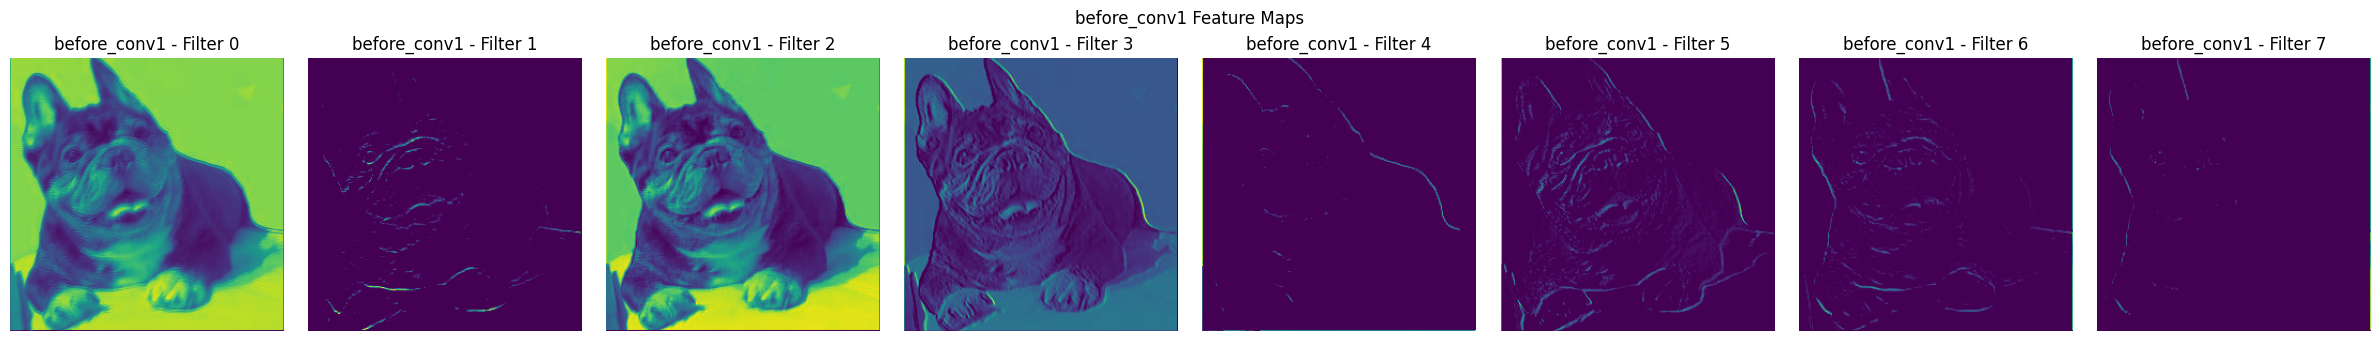

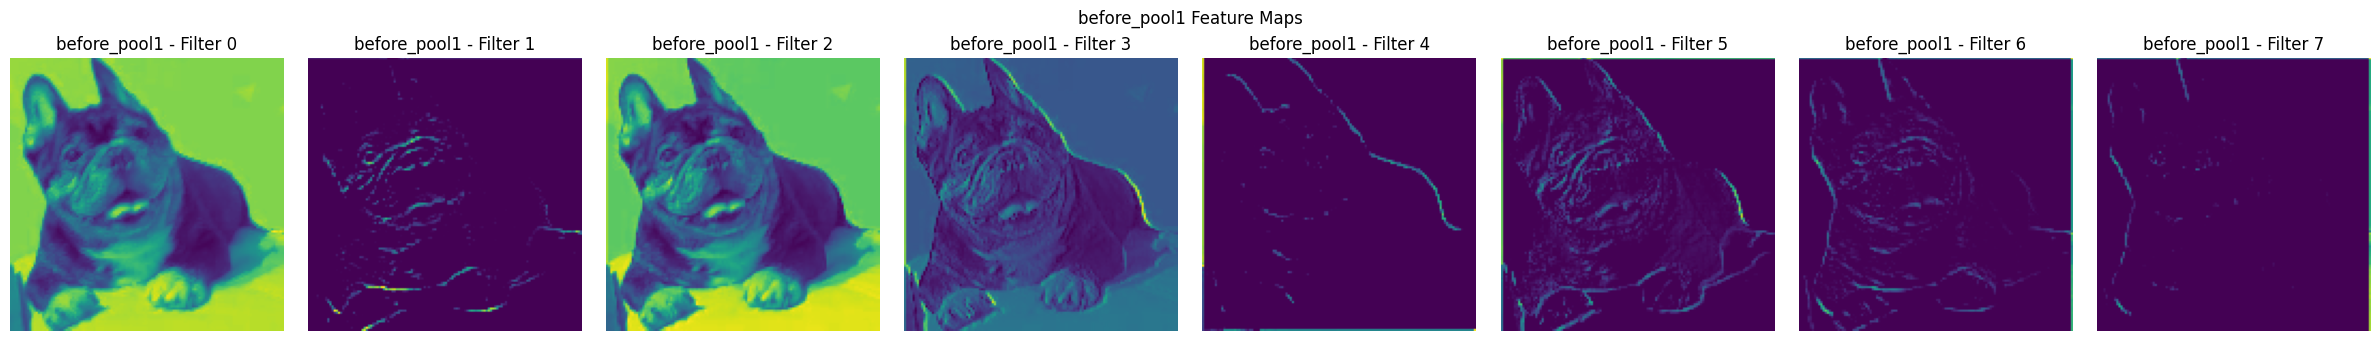

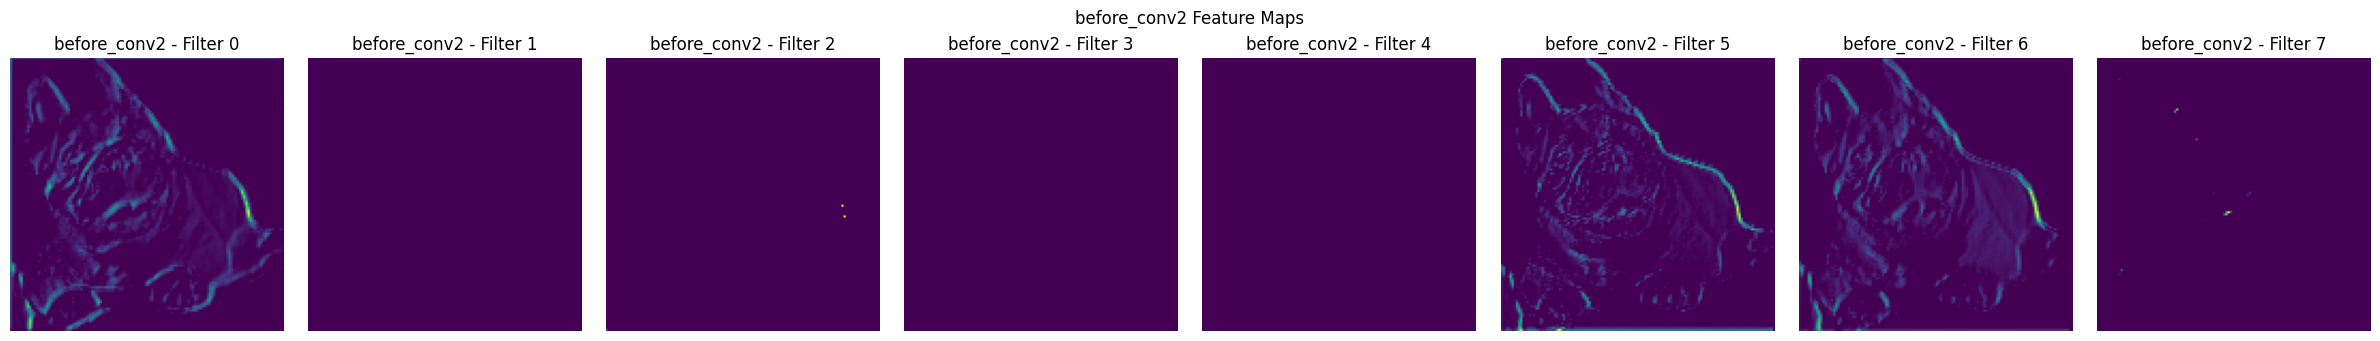

In [23]:
# conv1の特徴マップ出力を取得
before_maps = activation_model.predict(img_tensor_color)

# 取り出す
before_conv1_maps = before_maps[0]
before_pool1_maps = before_maps[1]
before_conv2_maps = before_maps[2]

# 可視化
visualize_feature_maps(before_conv1_maps, 'before_conv1')
visualize_feature_maps(before_pool1_maps, 'before_pool1')
visualize_feature_maps(before_conv2_maps, 'before_conv2')

In [12]:
# モデルをコンパイルする
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# モデルを学習させる
history = model.fit(
    x=train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.5372 - loss: 2068.3313 - val_accuracy: 0.6250 - val_loss: 25.8009
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 34s 100ms/step - accuracy: 0.6074 - loss: 40.6462 - val_accuracy: 0.6500 - val_loss: 25.7144
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.7313 - loss: 15.2784 - val_accuracy: 0.7000 - val_loss: 6.9769
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8497 - loss: 4.5760 - val_accuracy: 0.7375 - val_loss: 3.6507
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.9036 - loss: 1.4933 - val_accuracy: 0.6125 - val_loss: 11.2637
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.8265 - loss: 2.8650 - val_accuracy: 0.7250 - val_loss: 6.6928
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.9386 - loss: 0.8333 - val_accuracy: 0.7750 - val_loss: 4.8736
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.9586 - loss: 0.3685 - val_accurac

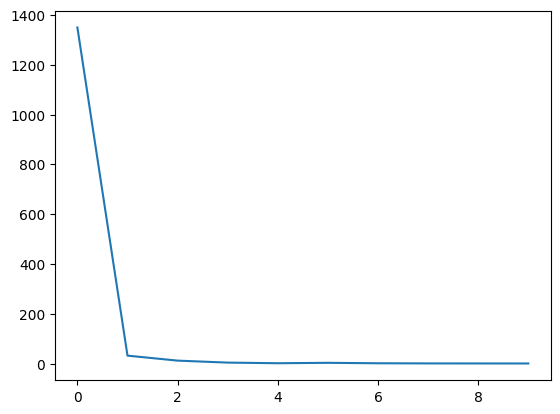

In [13]:
plt.plot(history.history['loss'], label='loss')

In [18]:
#比較
# conv1の特徴マップ出力を取得
after_maps = activation_model.predict(img_tensor_color)

# 取り出す
after_conv1_maps = after_maps[0]
after_pool1_maps = after_maps[1]
after_conv2_maps = after_maps[2]

# 可視化
visualize_feature_maps(before_conv1_maps, 'before_conv1', 8)
visualize_feature_maps(after_conv1_maps, 'after_conv1', 8)
visualize_diff_heat_maps(before_conv1_maps, after_conv1_maps,'conv1')

Output hidden; open in https://colab.research.google.com to view.

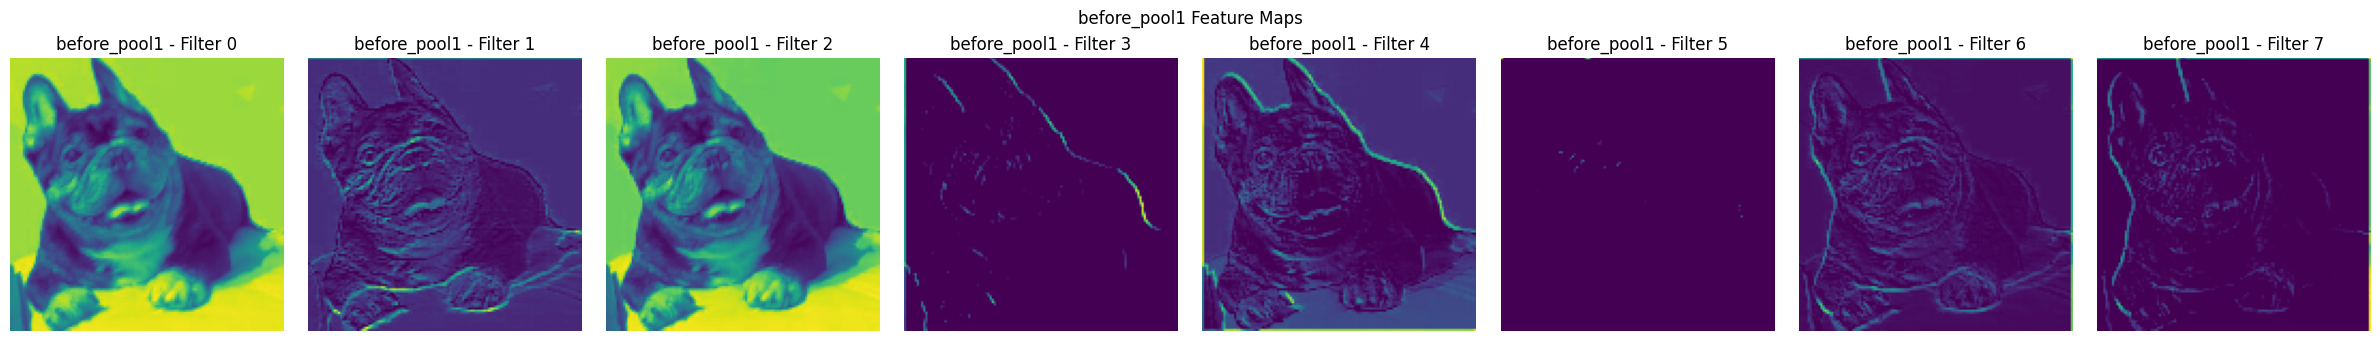

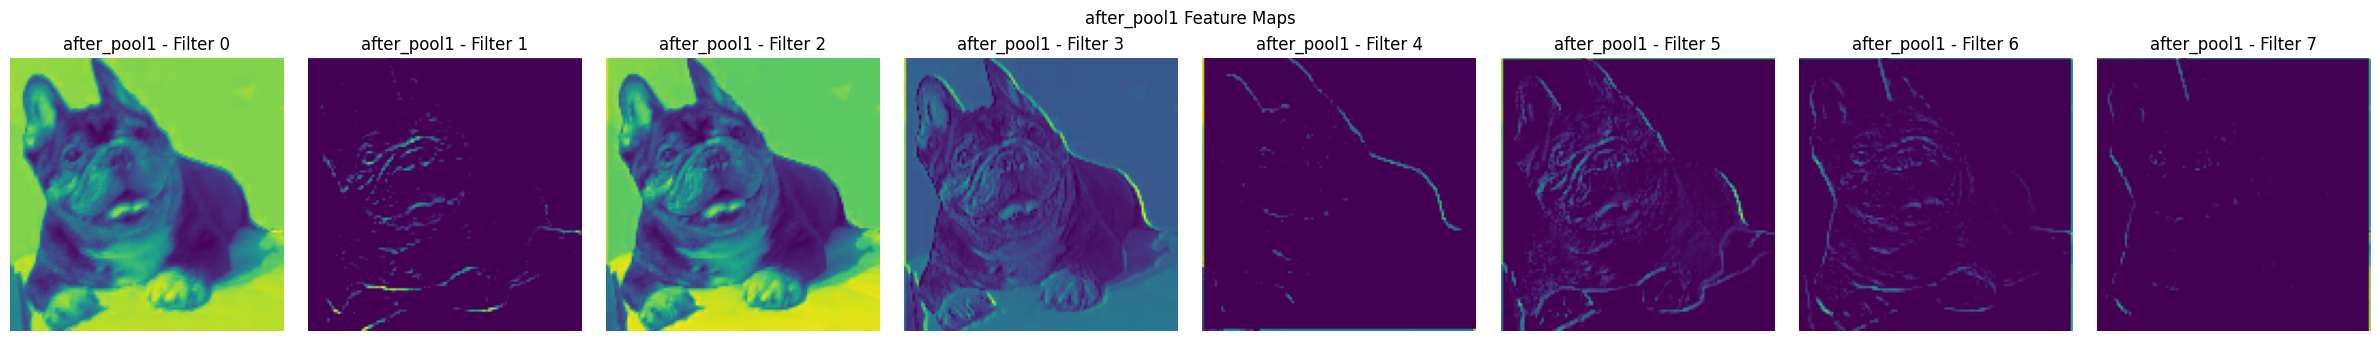

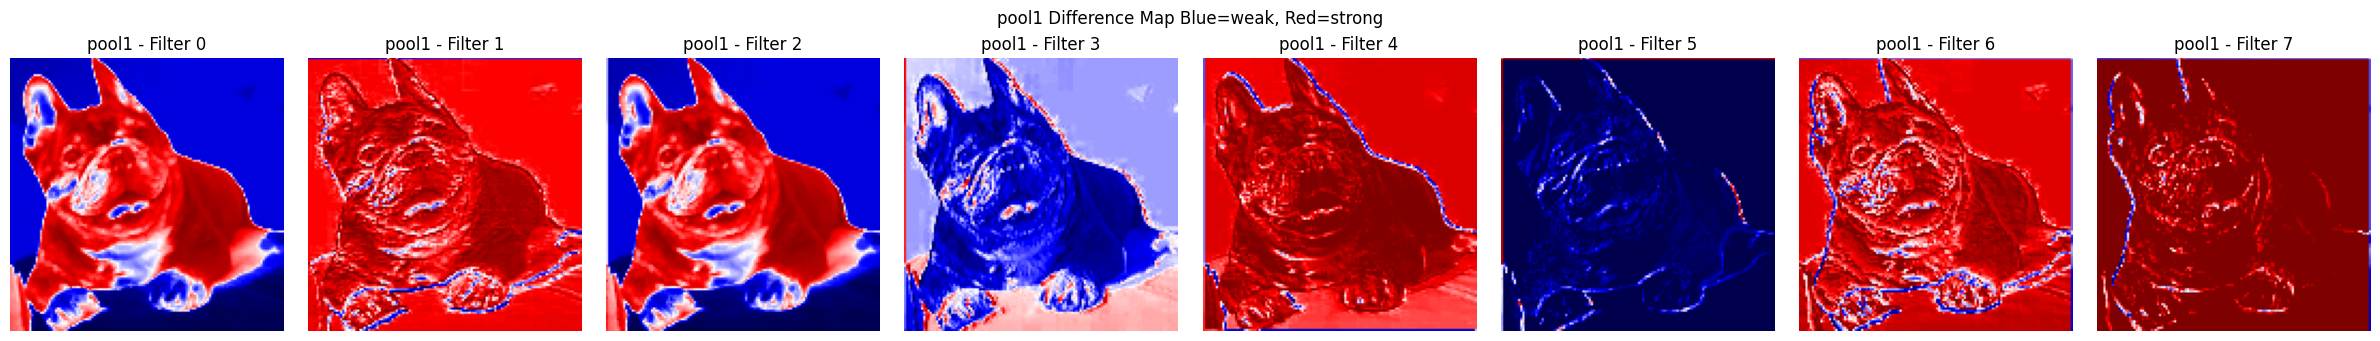

In [19]:
visualize_feature_maps(before_pool1_maps, 'before_pool1', 8)
visualize_feature_maps(after_pool1_maps, 'after_pool1', 8)
visualize_diff_heat_maps(before_pool1_maps, after_pool1_maps,'pool1')

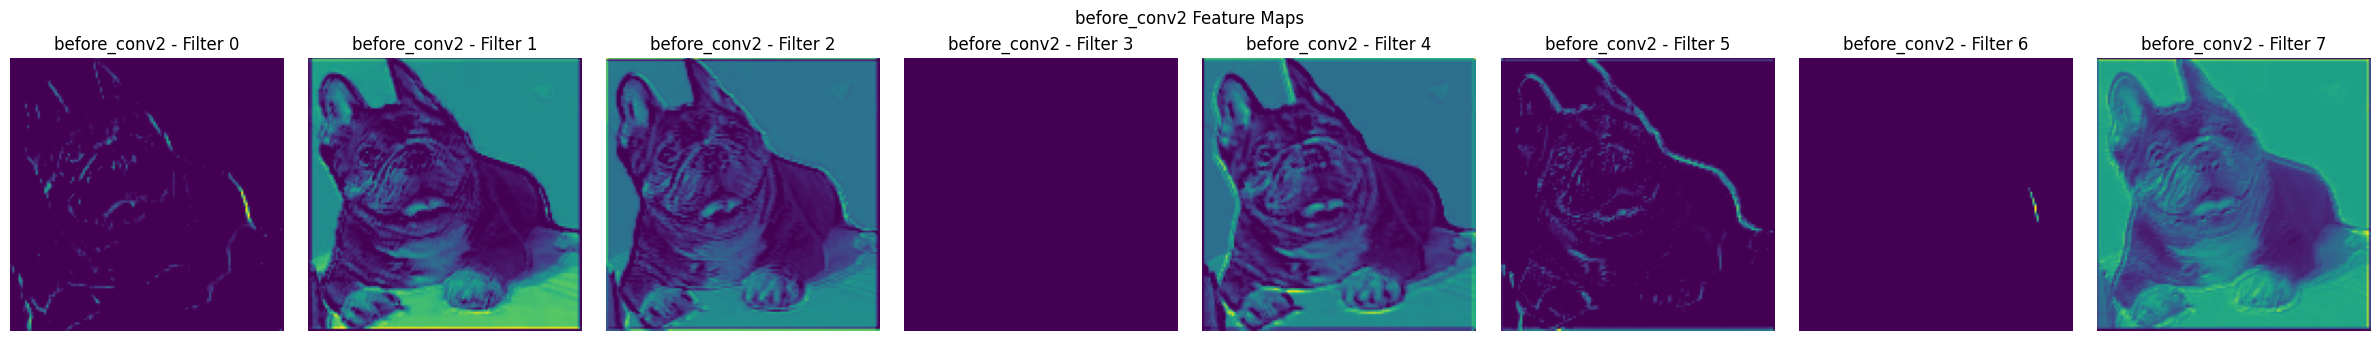

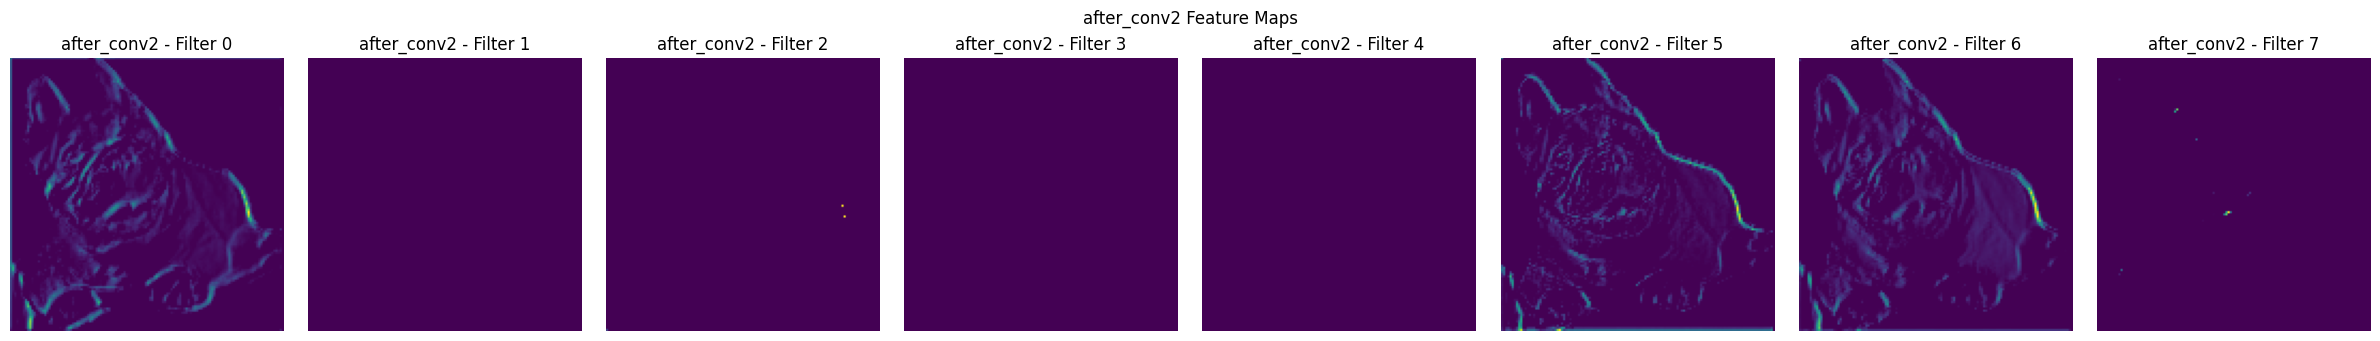

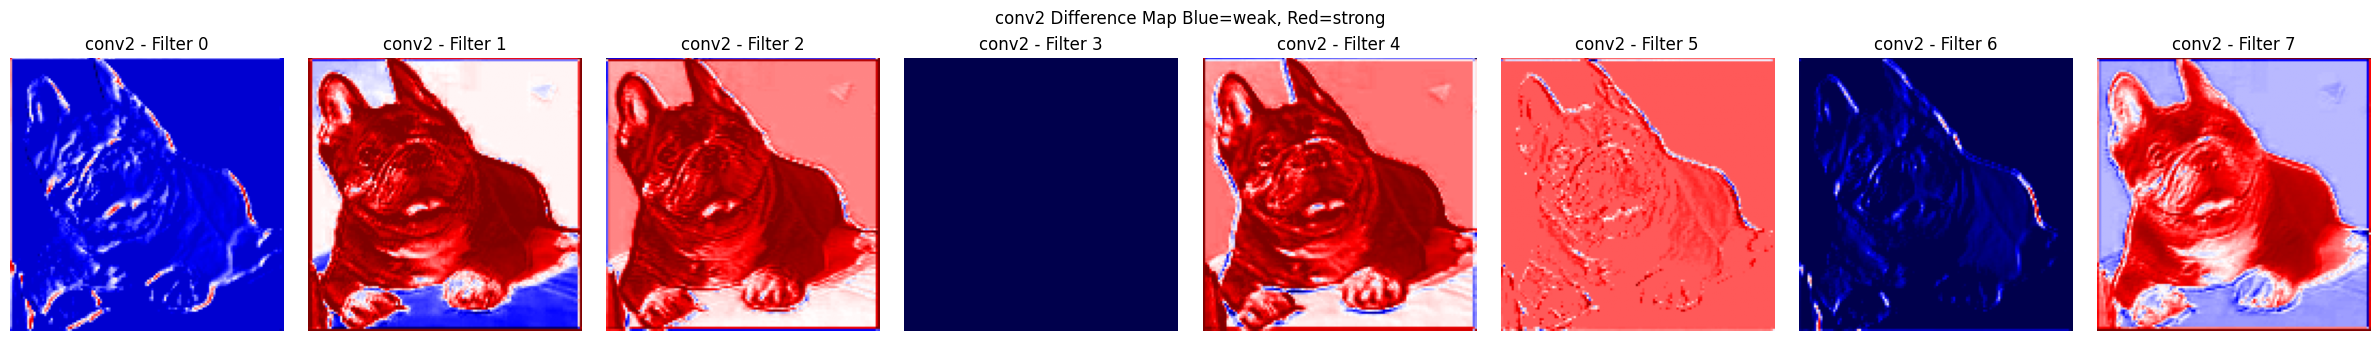

In [20]:
visualize_feature_maps(before_conv2_maps, 'before_conv2', 8)
visualize_feature_maps(after_conv2_maps, 'after_conv2', 8)
visualize_diff_heat_maps(before_conv2_maps, after_conv2_maps,'conv2')

In [24]:
# 保存
model.save_weights(f'/content/drive/MyDrive/cnn_visualization_workspace/model/cnn_french_dachs_2class.weights.h5')
model.save(f'/content/drive/MyDrive/cnn_visualization_workspace/model/cnn_french_dachs_2class.keras', include_optimizer=True)